In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import statsmodels.api as sm
import warnings
import os
!pip install openpyxl
warnings.filterwarnings('ignore', message='is not UTF-8 encoded')



data_dir = Path("final-group10/data")



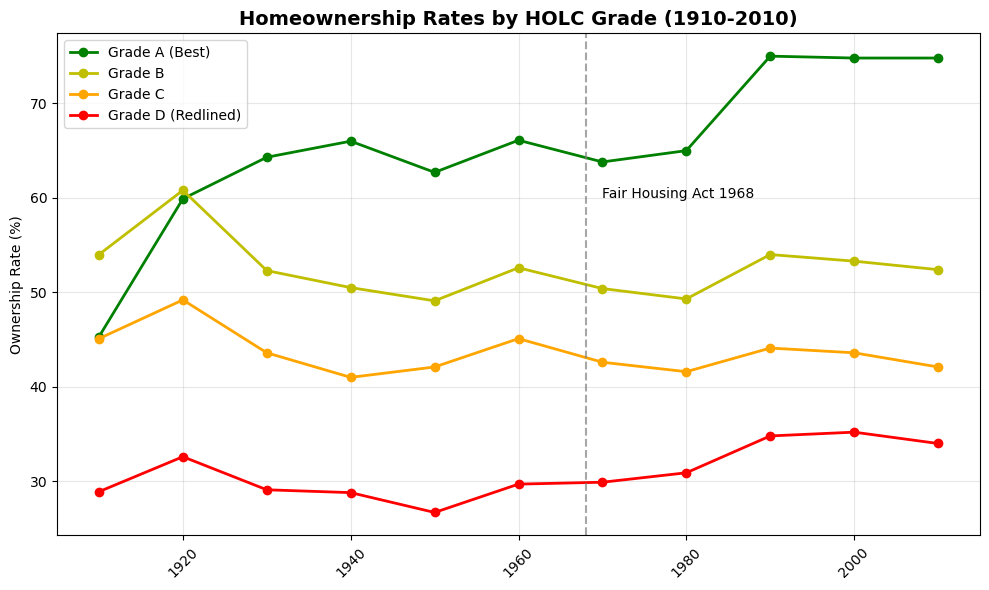

Key finding: D-grade areas stuck ~30% while A-grade reaches 75%


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_ownership['observation_date'], df_ownership['A'], 'go-', label='Grade A (Best)', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['B'], 'yo-', label='Grade B', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['C'], 'o-', color='orange', label='Grade C', linewidth=2)
plt.plot(df_ownership['observation_date'], df_ownership['D'], 'ro-', label='Grade D (Redlined)', linewidth=2)

plt.axvline(pd.to_datetime('1968-01-01'), color='gray', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('1970-01-01'), 60, 'Fair Housing Act 1968', rotation=0)

plt.title('Homeownership Rates by HOLC Grade (1910-2010)', fontsize=14, fontweight='bold')
plt.ylabel('Ownership Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/ownership_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print("Key finding: D-grade areas stuck ~30% while A-grade reaches 75%")


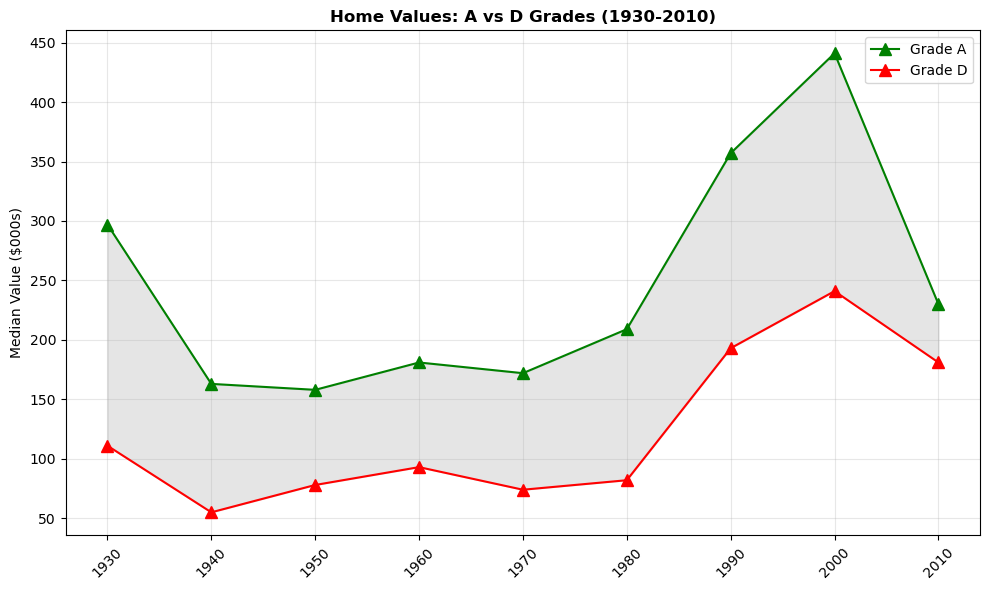

Key finding: A-grade values consistently 2-3x higher than D-grade


In [19]:
df_median = pd.read_excel("../data/median_value_HOLC.xlsx")

plt.figure(figsize=(10, 6))
plt.plot(df_median['observation_date'], df_median['A'], 'g^-', label='Grade A', markersize=8)
plt.plot(df_median['observation_date'], df_median['D'], 'r^-', label='Grade D', markersize=8)
plt.fill_between(df_median['observation_date'], df_median['A'], df_median['D'], alpha=0.2, color='gray')

plt.title('Home Values: A vs D Grades (1930-2010)', fontweight='bold')
plt.ylabel('Median Value ($000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/home_values_gap.png', dpi=300)
plt.show()

print("Key finding: A-grade values consistently 2-3x higher than D-grade")


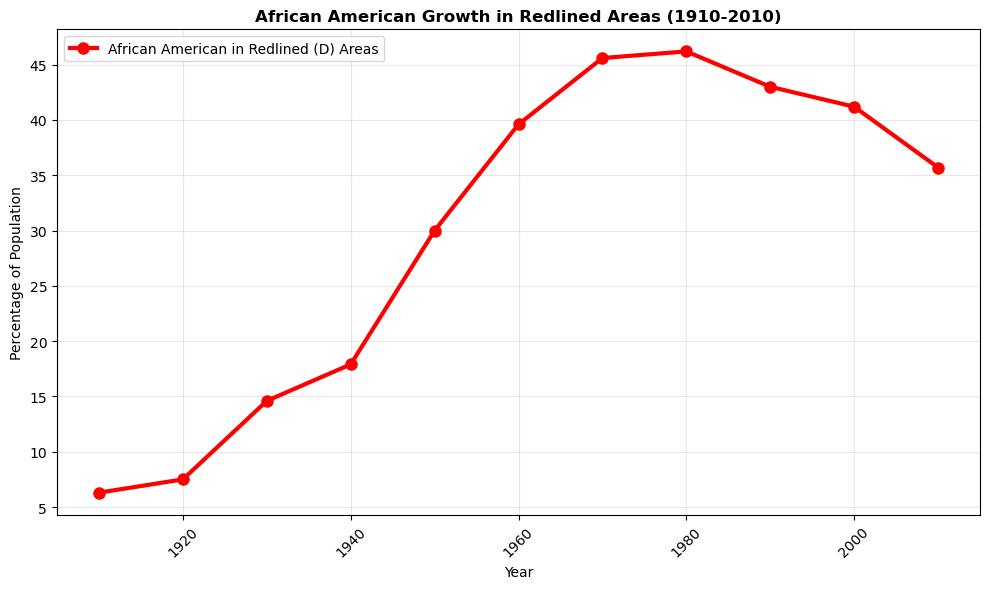

Key finding: D-areas AA population 6% → 36%


In [22]:
# Clean the messy headers (skip first row, use real column names)
df_demo = pd.read_excel("../data/share_of_African_Americans_and_Foreign_Born_HOLC.xlsx", 
                        skiprows=1)  # Skip "Frequency: 10 Year" row
df_demo.columns = ['date', 'FB_D', 'FB_A', 'FB_B', 'FB_C', 'AA_A', 'AA_B', 'AA_C', 'AA_D']

plt.figure(figsize=(10, 6))
plt.plot(df_demo['date'], df_demo['AA_D'], 'ro-', linewidth=3, markersize=8, 
         label='African American in Redlined (D) Areas')

plt.title('African American Growth in Redlined Areas (1910-2010)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/aa_redlined_growth.png', dpi=300)
plt.show()

print(f"Key finding: D-areas AA population {df_demo['AA_D'].iloc[0]:.0f}% → {df_demo['AA_D'].iloc[-1]:.0f}%")


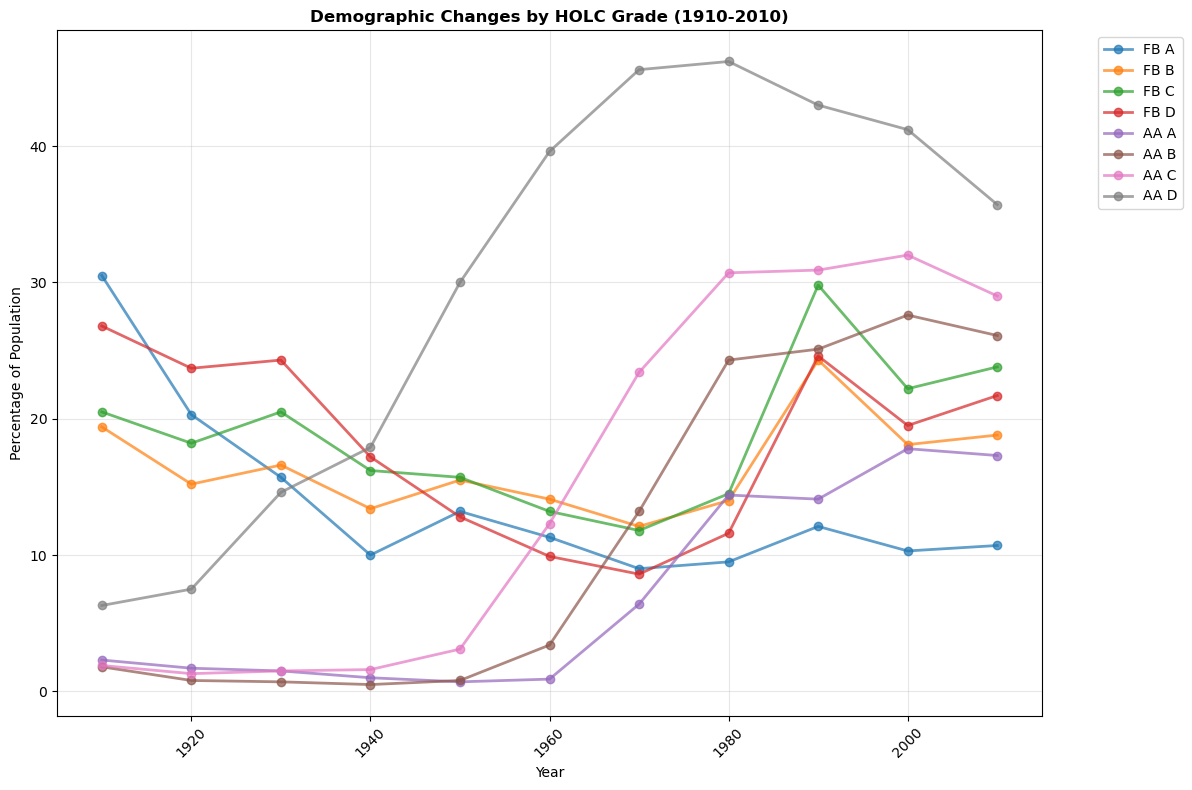

In [24]:
plt.figure(figsize=(12, 8))
grades = ['A', 'B', 'C', 'D']
colors = {'FB': 'blue', 'AA': 'red'}

for demo in ['FB', 'AA']:
    for grade in grades:
        col = f"{demo}_{grade}"
        plt.plot(df_demo['date'], df_demo[col], 'o-', label=f"{demo} {grade}", alpha=0.7, linewidth=2)

plt.title('Demographic Changes by HOLC Grade (1910-2010)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage of Population')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/all_demographics.png', dpi=300)
plt.show()
